In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
## importing the dataset
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()

In [8]:
## Independent feature
X = pd.DataFrame(data['data'], columns=data['feature_names'])
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [12]:
## dependent feture
y = pd.DataFrame(data['target'], columns=['Target'])
y.head()

,Target
0,0
1,0
2,0
3,0
4,0


In [14]:
## checking the balanceness of the dataset
y['Target'].value_counts()

Target
1    357
0    212
Name: count, dtype: int64

In [20]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve
import warnings
warnings.filterwarnings('ignore')

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

params = [{'C' : [0.01, 1, 2, 3, 4]}, {'max_iter': [100, 150]}]
model = LogisticRegression(C=100,max_iter=100)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

In [25]:
print("Accuracy of the model:", accuracy_score(y_test, y_pred), end='\n\n')
print("Classification report:\n\n")
print(classification_report(y_test, y_pred))

Accuracy of the model: 0.9521276595744681

Classification report:


              precision    recall  f1-score   support

           0       0.94      0.93      0.93        67
           1       0.96      0.97      0.96       121

    accuracy                           0.95       188
   macro avg       0.95      0.95      0.95       188
weighted avg       0.95      0.95      0.95       188



In [28]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[ 62,   5],
       [  4, 117]])

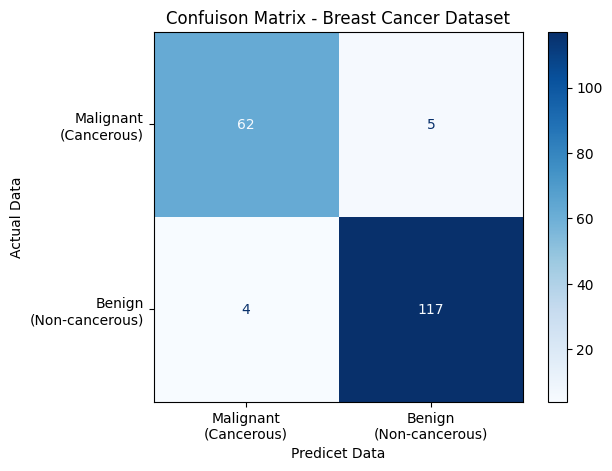

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels = ["Malignant\n(Cancerous)", "Benign\n(Non-cancerous)"], cmap='Blues')
plt.xlabel('Predicet Data')
plt.ylabel('Actual Data')
plt.title('Confuison Matrix - Breast Cancer Dataset')
plt.show()

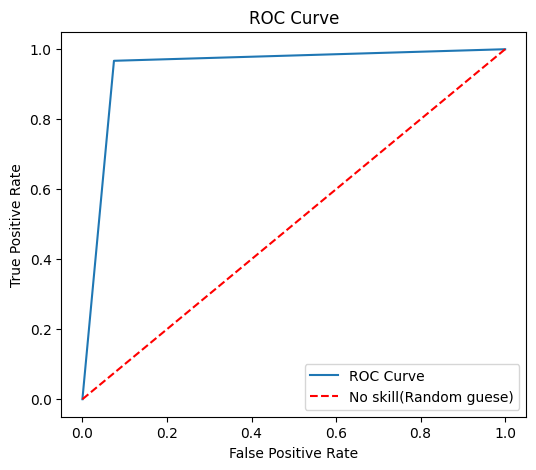

In [38]:
## Roc Curve - it give s the graph of true positve rate against the false positve rate. which means it gives idea
##about the how many it is predicting postive correctly against how many it is predicting the prositve wrongly

fpr, tpr, thresold = roc_curve(y_test, y_pred)
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1],[0,1],'r--', label='No skill(Random guese)')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()